# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [1]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import matplotlib.gridspec as gridspec
from itertools import combinations
import warnings

c:\Users\Getrude Kusa Echoka\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Getrude Kusa Echoka\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

1. Spending Across Store Locations

**Null Hypothesis (H₀):**  
There is no statistically significant difference in customer spending across City Center, Suburb, and Rural store locations.

**Statistical Form:**  
H₀: The distribution/median of Amount_Spent is the same across all store locations.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in customer spending across at least one store location.

**Statistical Form:**  
H₁: At least one store location has a different distribution/median of Amount_Spent.

**Plain Language:**  
Customers spend similar amounts regardless of whether they shop in City Center, Suburb, or Rural stores. The alternative is that spending patterns differ by location.


#### 2. Customer Satisfaction Across Store Locations

**Null Hypothesis (H₀):**  
There is no statistically significant difference in customer satisfaction ratings across City Center, Suburb, and Rural store locations.

**Statistical Form:**  
H₀: The distribution/median of Customer_Satisfaction is the same across all store locations.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in customer satisfaction ratings across at least one store location.

**Statistical Form:**  
H₁: At least one store location has a different distribution/median of Customer_Satisfaction.

**Plain Language:**  
Customers are equally satisfied across all store locations. The alternative is that satisfaction levels vary depending on the store location.


#### 3. Promotional vs Non-Promotional Spending

**Null Hypothesis (H₀):**  
There is no statistically significant difference in spending between promotional and non-promotional purchases.

**Statistical Form:**  
H₀: The distribution/median of Amount_Spent is the same for Promotional and Non-Promotional purchases.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in spending between promotional and non-promotional purchases.

**Statistical Form:**  
H₁: The distribution/median of Amount_Spent differs between Promotional and Non-Promotional purchases.

**Plain Language:**  
Customers spend the same amount whether there is a promotion or not. The alternative is that promotional periods are associated with different customer spending levels.


#### 4. Product Category Preferences Across Store Locations

**Null Hypothesis (H₀):**  
Product category preference is independent of store location.

**Statistical Form:**  
H₀: Store_Location and Product_Category are independent.

**Alternative Hypothesis (H₁):**  
Product category preference is associated with store location.

**Statistical Form:**  
H₁: Store_Location and Product_Category are not independent.

**Plain Language:**  
Customers in City Center, Suburb, and Rural stores have similar product category preferences. The alternative is that product preferences differ depending on store location.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

Minimum Detectable Effect (MDE) refers to the smallest difference or effect size that is considered meaningful enough for the business to act on. It is not only about whether a result is statistically significant, but whether the difference is large enough to matter in practical decision-making.

In this retail customer analysis, the MDE helps connect statistical testing to business relevance. For spending across locations, the business-relevant MDE is a difference of 15% or more. This means that even if spending differences are statistically significant, they should only influence location-specific strategies such as staffing, inventory allocation, or pricing if the difference is large enough to justify action. For customer satisfaction, the MDE is a 1.0-point difference on a 10-point scale because such a gap is noticeable and may require customer service improvements. For promotional spending, the MDE is a $15 increase because promotions usually reduce profit margins, so the company needs a large enough spending increase to justify the promotional cost.

MDE is important because large datasets can produce statistically significant results even when the actual difference is too small to be useful. At the same time, small samples may fail to detect real business effects. By defining the MDE before analysis, the company avoids overreacting to minor statistical differences and focuses instead on findings that are both statistically valid and commercially meaningful.


### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [2]:
# Load Data
df= pd.read_csv("retail_store_customer_data.csv", index_col= False)

# check for missing values
print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

# check the data types
print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

# check for inconsistencies
print("=" * 60)
print("1. BASIC DATASET INFO")
print("=" * 60)
print(df.info())

# check for duplicates
print("\n" + "=" * 60)
print("3. DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print(df[df.duplicated(keep=False)])  # shows all duplicate rows

# check for shape
print("\n" + "=" * 60)
print("Shape")
print("=" * 60)
print(df.shape)

# check for unique values
print("\n" + "=" * 60)
print("CHECKING UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 60)
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts())

# check summary statistics
print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
print(df.describe())


Missing Values
Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

Data Types
Store_Location               str
Customer_Satisfaction    float64
Product_Category             str
Purchase_Type                str
Amount_Spent             float64
dtype: object
1. BASIC DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   str    
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   str    
 3   Purchase_Type          1500 non-null   str    
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), str(3)
memory usage: 102.0 KB
None

3. DUPLICATE ROWS
Total duplicate rows: 0

Shape
(1500, 5)

CHECKING UNIQUE VALUES IN CATEGORICAL COLUMNS

S

C:\Users\Getrude Kusa Echoka\AppData\Local\Temp\ipykernel_17116\3614781332.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

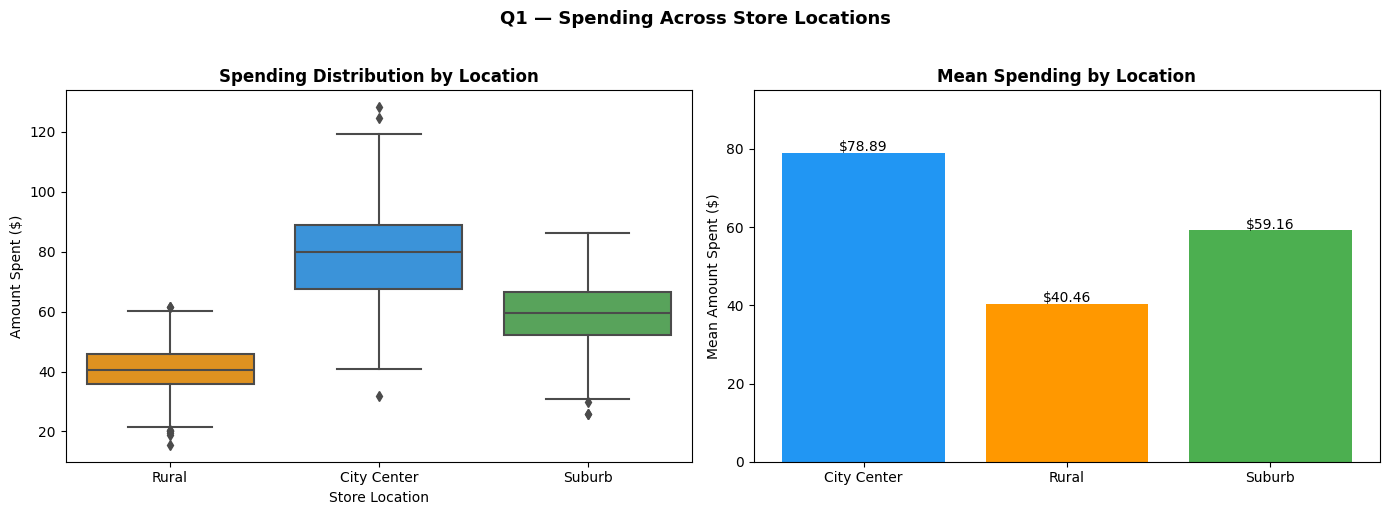

In [ ]:
# Visualize data - Create new cells as needed
# Conducting analysis of spending patterns here
# VIZ 1: Spending patterns across locations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'City Center': '#2196F3', 'Suburb': '#4CAF50', 'Rural': '#FF9800'}

# Box plot
sns.boxplot(data=df, x='Store_Location', y='Amount_Spent',
            palette=palette, ax=axes[0])
axes[0].set_title('Spending Distribution by Location', fontweight='bold')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Amount Spent ($)')

# Mean bar chart
means = df.groupby('Store_Location')['Amount_Spent'].mean().reset_index()
bars = axes[1].bar(means['Store_Location'], means['Amount_Spent'],
                   color=[palette[l] for l in means['Store_Location']], edgecolor='none')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${bar.get_height():.2f}', ha='center', fontsize=10)
axes[1].set_title('Mean Spending by Location', fontweight='bold')
axes[1].set_ylabel('Mean Amount Spent ($)')
axes[1].set_ylim(0, 95)

plt.suptitle('Q1 — Spending Across Store Locations', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_spending_location.png', dpi=150, bbox_inches='tight')
plt.show()

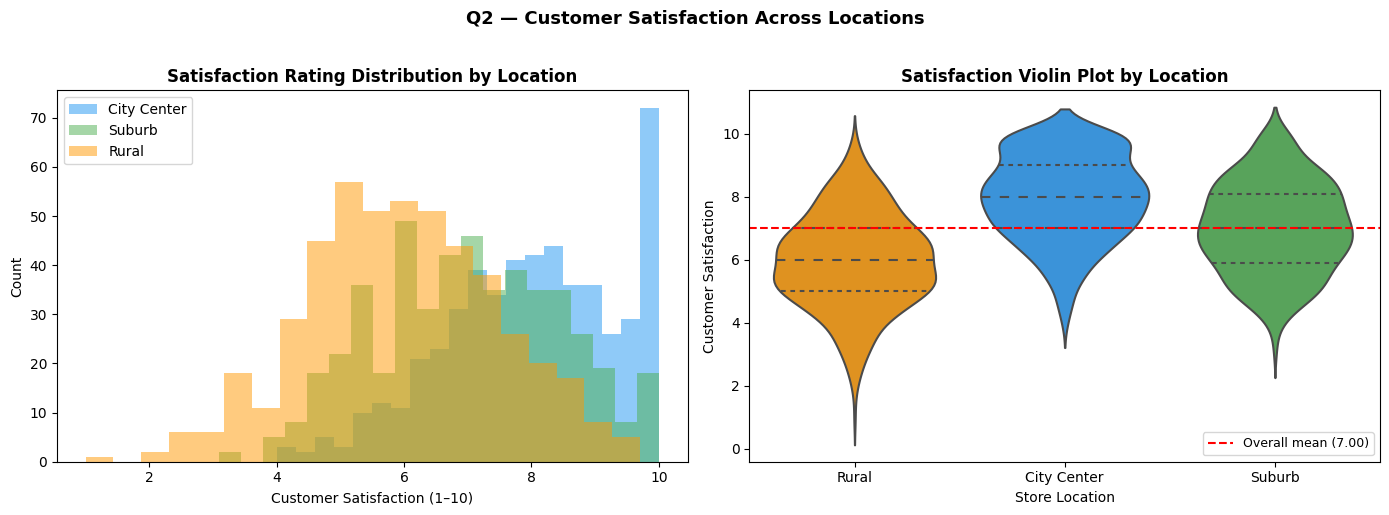

In [4]:
# VIZ 2: Satisfaction ratings distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for loc, color in palette.items():
    subset = df[df['Store_Location'] == loc]['Customer_Satisfaction']
    axes[0].hist(subset, bins=20, alpha=0.5, label=loc, color=color, edgecolor='none')
axes[0].set_title('Satisfaction Rating Distribution by Location', fontweight='bold')
axes[0].set_xlabel('Customer Satisfaction (1–10)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Violin plot
sns.violinplot(data=df, x='Store_Location', y='Customer_Satisfaction',
               palette=palette, inner='quartile', ax=axes[1])
axes[1].set_title('Satisfaction Violin Plot by Location', fontweight='bold')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Customer Satisfaction')
axes[1].axhline(df['Customer_Satisfaction'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Overall mean ({df["Customer_Satisfaction"].mean():.2f})')
axes[1].legend(fontsize=9)

plt.suptitle('Q2 — Customer Satisfaction Across Locations', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

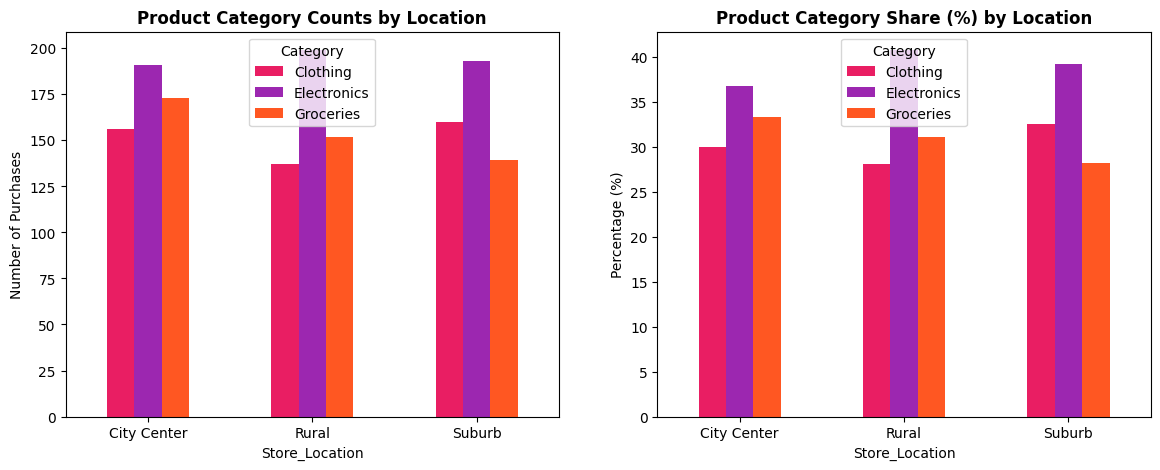

In [5]:
#  VIZ 3: Product category preferences 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['Store_Location'], df['Product_Category'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct.plot(kind='bar', ax=axes[0], color=['#E91E63','#9C27B0','#FF5722'],
        edgecolor='none', rot=0)
axes[0].set_title('Product Category Counts by Location', fontweight='bold')
axes[0].set_ylabel('Number of Purchases')
axes[0].legend(title='Category')

ct_pct.plot(kind='bar', ax=axes[1], color=['#E91E63','#9C27B0','#FF5722'],
            edgecolor='none', rot=0)
axes[1].set_title('Product Category Share (%) by Location', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Category')

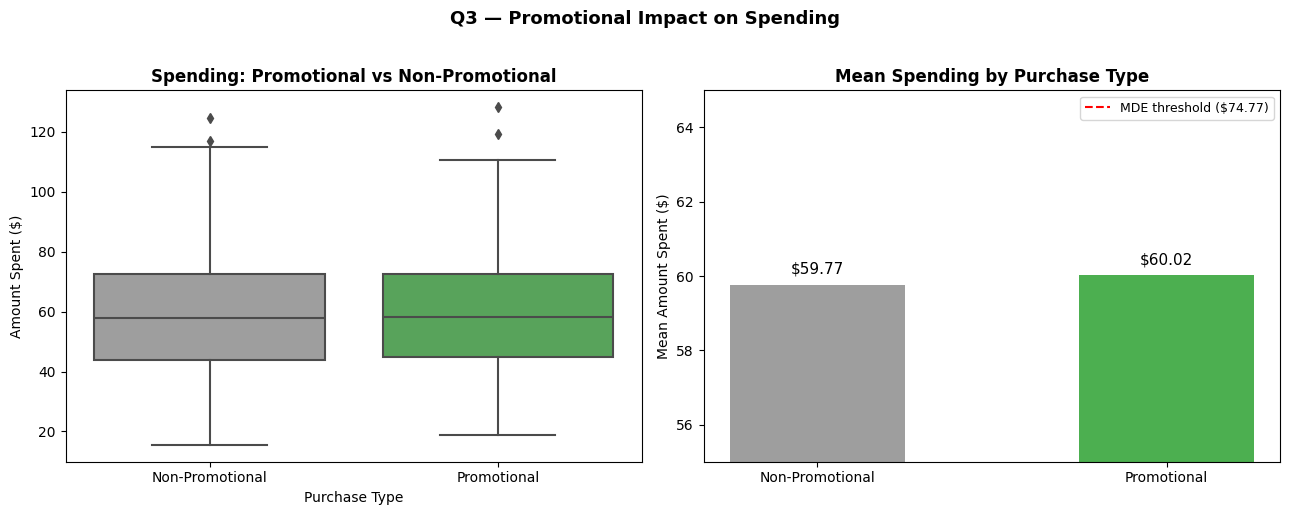

In [6]:
# IZ 4: Promotional vs Non-Promotional Spending
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
promo_palette = {'Promotional': '#4CAF50', 'Non-Promotional': '#9E9E9E'}

sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent',
            palette=promo_palette, ax=axes[0])
axes[0].set_title('Spending: Promotional vs Non-Promotional', fontweight='bold')
axes[0].set_xlabel('Purchase Type')
axes[0].set_ylabel('Amount Spent ($)')

promo_means = df.groupby('Purchase_Type')['Amount_Spent'].mean()
bars = axes[1].bar(promo_means.index, promo_means.values,
                   color=[promo_palette[k] for k in promo_means.index],
                   width=0.5, edgecolor='none')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${bar.get_height():.2f}', ha='center', fontsize=11)
axes[1].set_ylim(55, 65)
axes[1].set_title('Mean Spending by Purchase Type', fontweight='bold')
axes[1].set_ylabel('Mean Amount Spent ($)')
axes[1].axhline(59.77 + 15, color='red', linestyle='--',
                linewidth=1.5, label='MDE threshold ($74.77)')
axes[1].legend(fontsize=9)

plt.suptitle('Q3 — Promotional Impact on Spending', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_04_promo.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [ ]:
# Assumption tests and checks - Create new cells as needed
None

#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

[Write your answer here]

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [ ]:
# Conduct your analysis of spending patterns here
None

#### 3.2 Customer Satisfaction Analysis

In [ ]:
# Analyze customer satisfaction here
None

#### 3.3 Promotional Impact Analysis

In [ ]:
# Analyze the impact of promotions here
None

#### 3.4 Product Category Analysis

In [ ]:
# Analyze product category preferences here
None

### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [ ]:
# Calculate effect sizes - contrast with MDE
None

**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

[Write your answer here]

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

[Write your answer here]


In [ ]:
# Create visualizations to support results - Create new cells as needed
None

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

[Write your reflection here]

In [ ]:
%pip install scikit-posthocs

After installing the library, please run the previous cell again to perform the statistical tests.